# Quick Start: Understanding Drought Risk in 15 Minutes

## Introduction and Objective

Welcome! In this tutorial, you'll get hands-on experience with drought risk assessment under climate change. By the end of this 15-minute session, you'll understand the fundamental concept that 

**drought risk = hazard × exposure × vulnerability**, 

and you'll have created your first drought risk map for a European region.

### The Story

Imagine you're an urban planner in Central Greece (NUTS2 region EL64). Climate change is altering drought duration, but can we see an increasing risk? Is drought duration changing (hazard), does it affect agricultural land (exposure), and does farming depend entirely on rainfall rather than irrigation (vulnerability)? The answer: all three matter.

### What You'll Learn

- The IPCC drought risk framework
- How to download and process climate hazard data from the Copernicus Climate Data Store
- How to integrate exposure and vulnerability to assess overall risk
- Where to find more detailed information on each component

### What You'll Build

A map showing historical drought risk for Central Greece, combining:
- **Hazard**: Duration of meteorological droughts (1991-2020)
- **Exposure**: Agricultural land area
- **Vulnerability**: Rainfed crop dependence

> 💡 **Note.**
> This is a very simplified example to get you started quickly. For production analysis, see our [How-To Guides](../how-to-guides.ipynb) and [Explanation](../explanation.ipynb) sections.

Let's dive in!

---

## Setup

First, let's import the libraries we'll need:

In [46]:
import cdsapi
import zipfile
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import regionmask
from pathlib import Path

# Create a data directory
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

### Define your region of interest

Let's use ADMIN regions here, and specifically the "Central Greece" region as an example. This administrative region has the following ID: EL64. 


We'll set it here, then download the administative boundaries, define a bounding box, and use this id throughout this notebook.

In [47]:
admin_id = "EL64"

In [48]:
# Create regions subdirectory
regions_dir = data_dir / 'regions'
regions_dir.mkdir(exist_ok=True)

# Download NUTS admin region shapefiles if not already present
nuts_zip = regions_dir / 'NUTS_RG_20M_2024_4326.shp.zip'
if not nuts_zip.exists():
    import subprocess
    print("Downloading NUTS admin region shapefiles...")
    subprocess.run(['wget', 'https://gisco-services.ec.europa.eu/distribution/v2/nuts/shp/NUTS_RG_20M_2024_4326.shp.zip',
                    '-O', str(nuts_zip)], check=True)
    
    # Unzip the file
    print("Unzipping shapefiles...")
    with zipfile.ZipFile(nuts_zip, 'r') as zip_ref:
        zip_ref.extractall(regions_dir / 'NUTS_RG_20M_2024_4326')

# Read NUTS shapefiles
nuts_shp = regions_dir / 'NUTS_RG_20M_2024_4326' / 'NUTS_RG_20M_2024_4326.shp'
nuts_gdf = gpd.read_file(nuts_shp)

# Filter for EL64 region
sel_gdf = nuts_gdf[nuts_gdf['NUTS_ID'] == admin_id]
print(f"Found {admin_id} region: {sel_gdf.geometry.total_bounds}")


Found EL64 region: [21.39637798 37.98898161 24.67199242 39.27219519]


---

## 1. Hazard: Historical Drought Duration

Drought hazard represents the probability and severity of drought events. We'll use data from the **European Climate Data Explorer (ECDE)** and download it from the Copernicus Climate Data Store, which provides ready-to-use drought indicators.

> 📚 **Learn more**: For details on different drought types and indices, see [What is Drought?](../explanation/what_is_drought.md)

### Download Data

We'll download the duration of meteorological drought for the entire historical period. You'll need a CDS API key - see our [How-To Guide](../how-to-guides/download_data_from_cds.ipynb) for setup instructions.

In [49]:
# Initialize CDS API client
c = cdsapi.Client()

c.retrieve(
    "sis-ecde-climate-indicators",
    {
        "variable": ["duration_of_meteorological_droughts"],
        "origin": "reanalysis",
        "temporal_aggregation": ["yearly"],
        #"spatial_aggregation": "gridded"
        "spatial_aggregation": "regional_layer",
        "regional_layer": ["nuts_level_2"]
    }, 
    str(data_dir / 'drought_duration.zip')
)

print("Download complete!")

2026-01-29 12:48:43,180 INFO Request ID is f1c232b4-86a3-4788-8777-ed1665484c43
2026-01-29 12:48:43,219 INFO status has been updated to accepted
2026-01-29 12:48:51,525 INFO status has been updated to running
2026-01-29 12:48:56,632 INFO status has been updated to successful


2766277e7bda0e647575745aa02571e3.zip:   0%|          | 0.00/252k [00:00<?, ?B/s]

Download complete!


> ⏱️ **Time-saving tip**: For this tutorial, we'll work with pre-processed data. In practice, this download takes 10-15 minutes.

### Unzip and Identify the Downloaded File

In [51]:
# Unzip the downloaded file
with zipfile.ZipFile(data_dir / 'drought_duration.zip', 'r') as zip_ref:
    #zip_ref.extractall(data_dir)
    # List all files in the zip
    file_list = zip_ref.namelist()
    print(f"Files in drought_duration.zip")
    for f in file_list:
        print(f"  - {f}")
    
    # Find the NetCDF file (typically the largest or with .nc extension)
    nc_files_in_zip = [f for f in file_list if f.endswith('.nc')]
    
    if nc_files_in_zip:
        hazard_file = nc_files_in_zip[0]
        print(f"Using file: {hazard_file}")
        zip_ref.extract(hazard_file, data_dir)
    else:
        print("No NetCDF file found in zip!")

Files in drought_duration.zip
  - 19_duration_of_meteorological_droughts-reanalysis-yearly-layer-nuts_2-latitude-1940-2023-v1.0.nc
Using file: 19_duration_of_meteorological_droughts-reanalysis-yearly-layer-nuts_2-latitude-1940-2023-v1.0.nc


### Load and Process Hazard Data

In [53]:
# Load the drought duration dataset
hazard_ds = xr.open_dataset(data_dir / hazard_file)

# Explore the dataset structure
print("Dataset variables:", list(hazard_ds.data_vars))
print("Dataset dimensions:", dict(hazard_ds.dims))
print("Coordinate variables:", list(hazard_ds.coords))

# Display the dataset
hazard_ds

Dataset variables: ['dmd']
Dataset dimensions: {'nuts': 334, 'time': 84}
Coordinate variables: ['realization', 'time', 'nuts']


/etc/ecmwf/ssd/ssd1/jupyterhub/nejk-jupyterhub/tmpdirs/nejk.47883777/ipykernel_695538/680448061.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dataset dimensions:", dict(hazard_ds.dims))


<xarray.Dataset> Size: 230kB
Dimensions:      (nuts: 334, time: 84)
Coordinates:
  * nuts         (nuts) <U4 5kB 'DE50' 'DE60' 'DE71' ... 'NO06' 'NO07' 'NO08'
  * time         (time) datetime64[ns] 672B 1940-01-01 1941-01-01 ... 2023-01-01
    realization  int64 8B ...
Data variables:
    dmd          (nuts, time) float64 224kB ...

### Filter for Central Greece and visualize hazard

In [54]:
### Filter for Central Greece (NUTS2: EL64)
# Check the NUTS codes available
print("First 10 NUTS codes:", hazard_ds['nuts'].values[:10])

# Filter for Central Greece (EL64)
hazard_region = hazard_ds.sel(nuts=admin_id)

print(f"\nCentral Greece ({admin_id}):")
print(f"Time range: {hazard_region['time'].values[0]} to {hazard_region['time'].values[-1]}")
print(f"Number of time steps: {len(hazard_region['time'])}")

First 10 NUTS codes: ['DE50' 'DE60' 'DE71' 'DE72' 'DE73' 'DE80' 'DE91' 'BG41' 'BG42' 'CH01']

Central Greece (EL64):
Time range: 1940-01-01T00:00:00.000000000 to 2023-01-01T00:00:00.000000000
Number of time steps: 84


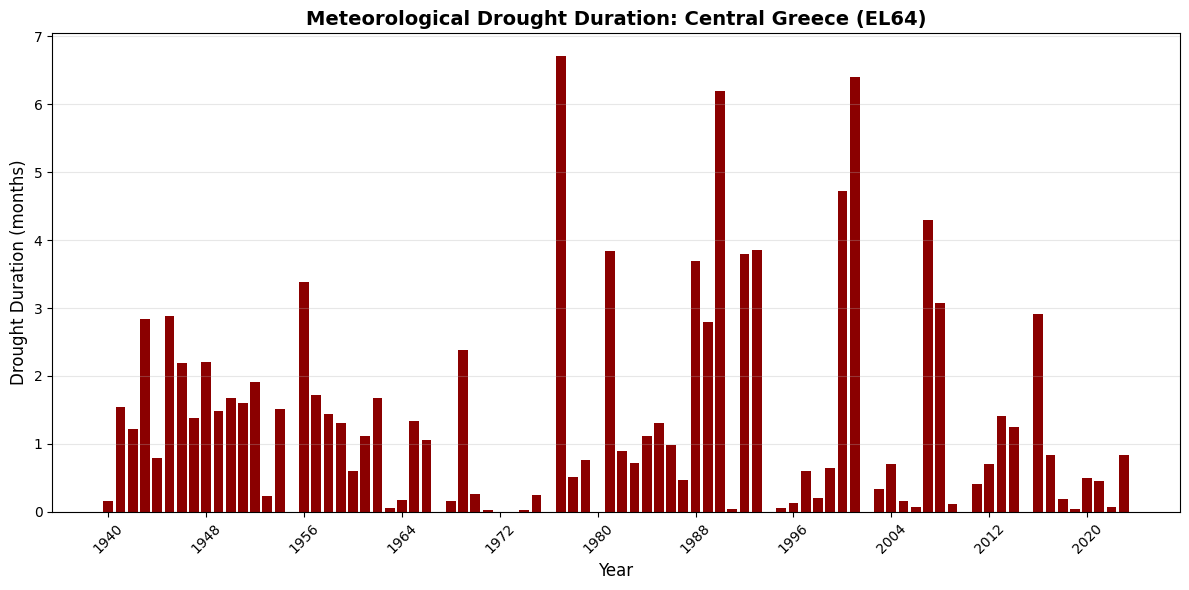


Drought Duration Statistics:
Mean: 1.30 months
Min: 0.00 months
Max: 6.71 months


In [9]:
### Visualize Hazard Time Series
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the time series as a bar chart
ax.bar(range(len(hazard_region['time'])), hazard_region['dmd'].values, color='darkred', width=0.8)

ax.set_title('Meteorological Drought Duration: Central Greece (EL64)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought Duration (months)', fontsize=12)
ax.set_xticks(range(0, len(hazard_region['time']), max(1, len(hazard_region['time'])//10)))
ax.set_xticklabels([str(t.astype('datetime64[Y]')) for t in hazard_region['time'].values[::max(1, len(hazard_region['time'])//10)]], rotation=45)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print some statistics
print(f"\nDrought Duration Statistics:")
print(f"Mean: {hazard_region['dmd'].mean().values:.2f} months")
print(f"Min: {hazard_region['dmd'].min().values:.2f} months")
print(f"Max: {hazard_region['dmd'].max().values:.2f} months")

**What we see**: The time series shows how drought duration has varied over time in Central Greece, revealing major drought events and potential trends.

---

## 2. Exposure: Agricultural Land

Exposure tells us what's at stake. Not all land is equally vulnerable to drought - agricultural areas are typically more exposed than forests or urban areas.

> 📚 **Learn more**: See [Understanding Exposure](../explanation/exposure.md) for different exposure metrics.

### Load Agricultural Land Fraction Data

We'll use pre-calculated agricultural land fraction data from the CSV file created in our how-to guide:

In [55]:
# Read the agricultural land fraction CSV file
ag_csv_file = data_dir / f'agricultural_land_fraction_{admin_id}.csv'
ag_data_df = pd.read_csv(ag_csv_file)

print(f"Loaded agricultural land fraction data:")
print(f"  Years available: {ag_data_df['year'].min()}-{ag_data_df['year'].max()}")
print(f"  Mean fraction: {ag_data_df['ag_fraction'].mean()*100:.1f}%")

Loaded agricultural land fraction data:
  Years available: 1992-1995
  Mean fraction: 30.4%


### Create Exposure Timeseries with Persistence

In [56]:
# Get the years from the hazard dataset
hazard_years = pd.to_datetime(hazard_region['time'].values).year.values

# Create a complete timeseries matching hazard years with persistence
ag_timeseries = []
for year in hazard_years:
    # Find the closest available year in the CSV (with forward fill/persistence)
    if year <= ag_data_df['year'].min():
        # Use first available year
        ag_frac = ag_data_df[ag_data_df['year'] == ag_data_df['year'].min()]['ag_fraction'].values[0]
    elif year >= ag_data_df['year'].max():
        # Use last available year (persistence)
        ag_frac = ag_data_df[ag_data_df['year'] == ag_data_df['year'].max()]['ag_fraction'].values[0]
    elif year in ag_data_df['year'].values:
        # Exact match
        ag_frac = ag_data_df[ag_data_df['year'] == year]['ag_fraction'].values[0]
    else:
        # Use the most recent available year (forward fill)
        available_years = ag_data_df[ag_data_df['year'] < year]['year'].values
        if len(available_years) > 0:
            most_recent = available_years.max()
            ag_frac = ag_data_df[ag_data_df['year'] == most_recent]['ag_fraction'].values[0]
        else:
            ag_frac = ag_data_df['ag_fraction'].iloc[0]
    
    ag_timeseries.append(ag_frac)

ag_timeseries = np.array(ag_timeseries)

print(f"\nCreated agricultural fraction timeseries:")
print(f"  Length: {len(ag_timeseries)} years")
print(f"  Range: {ag_timeseries.min()*100:.1f}% - {ag_timeseries.max()*100:.1f}%")
print(f"  Mean: {ag_timeseries.mean()*100:.1f}%")
print(f"\nYears using persistence: {sum(~np.isin(hazard_years, ag_data_df['year'].values))}")


Created agricultural fraction timeseries:
  Length: 84 years
  Range: 30.1% - 30.5%
  Mean: 30.3%

Years using persistence: 80


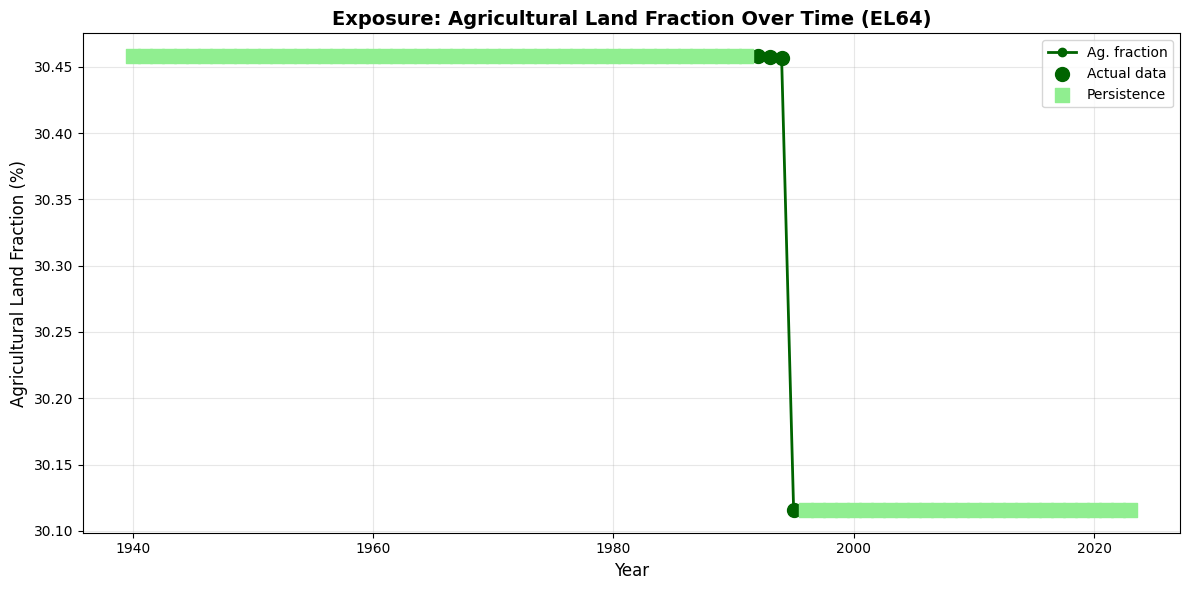


Agricultural land coverage in EL64: 30.3% (mean over all years)


In [57]:
# Visualize the exposure timeseries
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(hazard_years, ag_timeseries * 100, marker='o', linewidth=2, markersize=6, color='darkgreen', label='Ag. fraction')

# Mark the years where we have actual data vs persistence
actual_data_mask = np.isin(hazard_years, ag_data_df['year'].values)
ax.scatter(hazard_years[actual_data_mask], ag_timeseries[actual_data_mask] * 100, 
          color='darkgreen', s=100, zorder=5, label='Actual data', marker='o')
ax.scatter(hazard_years[~actual_data_mask], ag_timeseries[~actual_data_mask] * 100, 
          color='lightgreen', s=100, zorder=5, label='Persistence', marker='s')

ax.set_title(f'Exposure: Agricultural Land Fraction Over Time ({admin_id})', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Agricultural Land Fraction (%)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nAgricultural land coverage in {admin_id}: {ag_timeseries.mean()*100:.1f}% (mean over all years)")

**What we see**: The timeseries shows how agricultural land fraction has evolved, with actual measurements (circles) and persistence assumptions (squares) for years without data.

### Agricultural Drought Impact Over Time

Now let's combine the hazard (drought duration) with exposure (agricultural land) to see how drought impacts on agriculture have evolved:

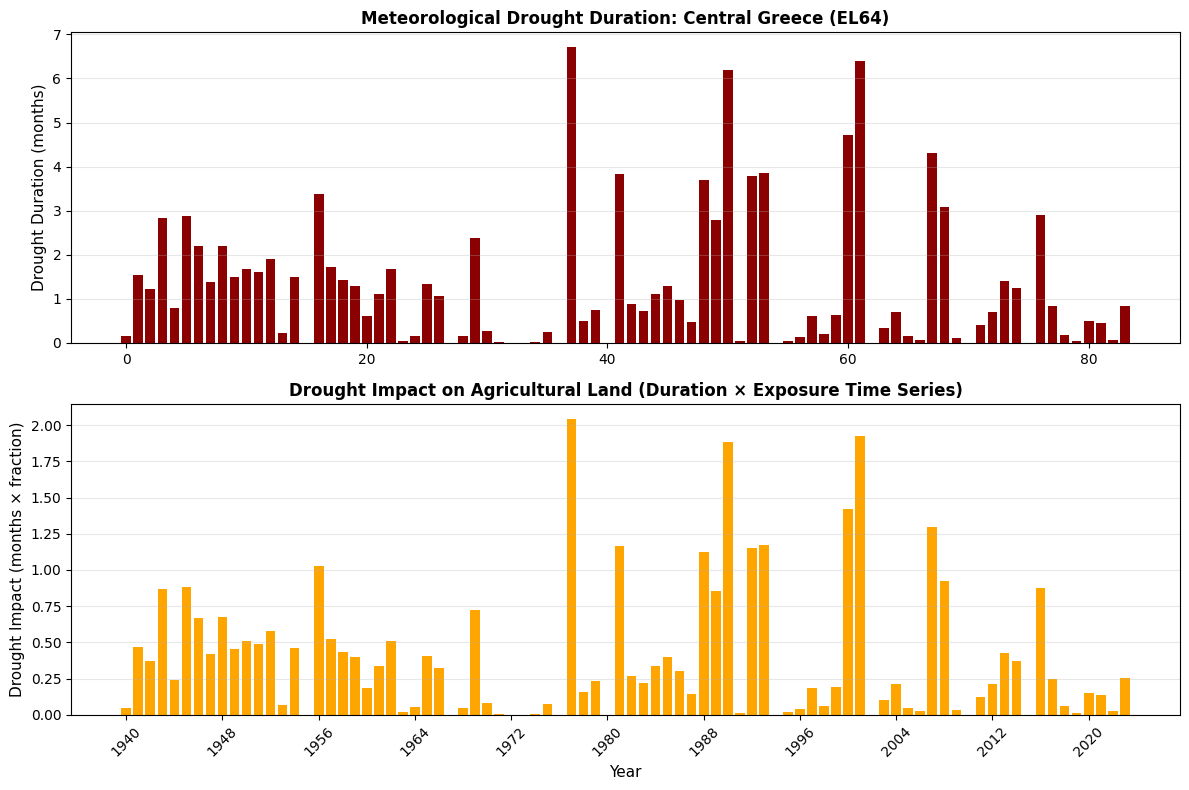

Drought Impact Summary:
Mean agricultural land: 30.3%
Mean annual impact: 0.40 months
Worst year: 2.04 months (in year 1977)
Best year: 0.00 months (in year 1955)


In [58]:
# Calculate drought impact on agricultural areas
# Impact = drought duration × fraction of agricultural land (time-varying)
agricultural_drought_impact = hazard_region['dmd'].values * ag_timeseries

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Original drought duration
ax1.bar(range(len(hazard_region['time'])), hazard_region['dmd'].values, color='darkred', width=0.8)
ax1.set_title('Meteorological Drought Duration: Central Greece (EL64)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Drought Duration (months)', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Drought impact on agricultural land
ax2.bar(range(len(hazard_region['time'])), agricultural_drought_impact, color='orange', width=0.8)
ax2.set_title('Drought Impact on Agricultural Land (Duration × Exposure Time Series)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Drought Impact (months × fraction)', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

# Set consistent x-axis labels
years_subset = hazard_region['time'].values[::max(1, len(hazard_region['time'])//10)]
years_labels = [str(t.astype('datetime64[Y]')) for t in years_subset]
tick_positions = range(0, len(hazard_region['time']), max(1, len(hazard_region['time'])//10))
ax2.set_xticks(tick_positions)
ax2.set_xticklabels(years_labels, rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Drought Impact Summary:")
print(f"Mean agricultural land: {ag_timeseries.mean()*100:.1f}%")
print(f"Mean annual impact: {agricultural_drought_impact.mean():.2f} months")
print(f"Worst year: {agricultural_drought_impact.max():.2f} months (in year {hazard_region['time'].values[np.argmax(agricultural_drought_impact)].astype('datetime64[Y]')})")
print(f"Best year: {agricultural_drought_impact.min():.2f} months (in year {hazard_region['time'].values[np.argmin(agricultural_drought_impact)].astype('datetime64[Y]')})")

---

## 4. Vulnerability: Rainfed Agriculture Dependence

Vulnerability represents the susceptibility of exposed elements to harm. A region with extensive irrigation is less vulnerable to drought than one relying entirely on rainfall.

> 📚 **Learn more**: For the full IPCC vulnerability framework, see [Understanding Vulnerability](../explanation/vulnerability.md)

### Load Vulnerability Data

We'll use irrigation data from AQUASTAT to estimate the fraction of rainfed (non-irrigated) agriculture:

In [ ]:
# For this tutorial, we'll use simplified country-level data
# In practice, you'd want higher spatial resolution - see our How-To Guides

# Example: Greece has approximately 60% rainfed agriculture
# (This is a simplification - actual data would vary spatially)
vulnerability = xr.full_like(exposure_regrid, 0.6)

# You could refine this with actual gridded irrigation data:
# vulnerability_refined = 1 - (irrigated_area / total_agricultural_area)

print(f"Using rainfed fraction as vulnerability proxy: {vulnerability.mean().values:.2f}")

### Visualize Vulnerability

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
vulnerability.plot(ax=ax, cmap='Blues', cbar_kwargs={'label': 'Rainfed Fraction'})
ax.set_title('Drought Vulnerability: Rainfed Agriculture Dependence')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

---

## 5. The Complete Picture: Drought Risk

Now we bring it all together. **Risk = Hazard × Exposure × Vulnerability**

In [ ]:
# Calculate overall drought risk
drought_risk = hazard_mean * exposure_regrid * vulnerability

# Normalize for visualization
drought_risk_norm = (drought_risk - drought_risk.min()) / (drought_risk.max() - drought_risk.min())

### Final Comparison

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Hazard
im1 = hazard_mean.plot(ax=axes[0, 0], cmap='YlOrRd', add_colorbar=False)
axes[0, 0].set_title('(a) Hazard\nDrought Duration', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[0, 0], label='Months')

# Exposure
im2 = exposure_regrid.plot(ax=axes[0, 1], cmap='Greens', add_colorbar=False)
axes[0, 1].set_title('(b) Exposure\nAgricultural Land', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axes[0, 1], label='Fraction')

# Vulnerability
im3 = vulnerability.plot(ax=axes[1, 0], cmap='Blues', add_colorbar=False)
axes[1, 0].set_title('(c) Vulnerability\nRainfed Dependence', fontsize=12, fontweight='bold')
plt.colorbar(im3, ax=axes[1, 0], label='Fraction')

# Risk
im4 = drought_risk_norm.plot(ax=axes[1, 1], cmap='RdPu', add_colorbar=False)
axes[1, 1].set_title('(d) Risk = Hazard × Exposure × Vulnerability\nDrought Risk', 
                     fontsize=12, fontweight='bold')
plt.colorbar(im4, ax=axes[1, 1], label='Normalized Risk')

plt.tight_layout()
plt.show()

### Interpret the Results

In [ ]:
# Find the highest risk areas
risk_threshold = drought_risk_norm.quantile(0.9)
high_risk_areas = drought_risk_norm > risk_threshold

print(f"High risk areas cover {high_risk_areas.sum().values / high_risk_areas.size * 100:.1f}% of the region")
print(f"\nInterpretation:")
print(f"- Mean hazard: {hazard_mean.mean().values:.1f} months of drought")
print(f"- Agricultural exposure: {exposure_regrid.mean().values*100:.1f}% of land")
print(f"- Rainfed vulnerability: {vulnerability.mean().values*100:.1f}%")
print(f"- Overall risk is highest where all three factors coincide")

---

## Summary and Next Steps

**Congratulations!** 🎉 You've just completed your first drought risk assessment. You now understand:

1. **The risk framework**: Risk emerges from the combination of hazard, exposure, and vulnerability
2. **How to access climate data**: Using the Copernicus Climate Data Store
3. **Why all three components matter**: High hazard alone doesn't equal high risk without exposure and vulnerability

### What You Created

- A spatial map of drought risk for Central Greece
- An understanding of which factors drive risk in different locations
- A foundation for more sophisticated analysis

### Next Steps

Ready to go deeper? Here's your learning path:

**Tutorials** (hands-on practice):
- [Historical Drought Analysis](historical_drought.ipynb) - Analyze trends over time
- [Projected Drought](projected_drought.ipynb) - Explore future scenarios
- [Exposure Analysis](exposure_land.ipynb) - Work with different exposure metrics

**How-To Guides** (specific tasks):
- [Download Data from CDS](../how-to-guides/download_data_from_cds.ipynb) - Set up API access
- [Define Your Region](../how-to-guides/define_your_region.ipynb) - Work with NUTS regions
- [Compare Regions](../how-to-guides/compare_regions.ipynb) - Analyze multiple areas

**Explanation** (deeper understanding):
- [What is Drought?](../explanation/what_is_drought.md) - Meteorological, agricultural, hydrological
- [The IPCC Risk Framework](../explanation/drought_risk.md) - Conceptual foundations
- [Interpreting Results](../explanation/interpretation.md) - Common pitfalls and best practices

**References** (technical details):
- [ECDE Dataset Documentation](../references/ecde_data.md)
- [VALORADA Project](../references/valorada.md)

---

## Questions or Issues?

- Found a bug? Open an issue on our GitHub repository
- Have a question? Check our FAQ or discussion forum
- Want to contribute? See our contribution guidelines

Happy analyzing! 🌍💧